# Notebook 1 — Maximum-Likelihood Training with Monte-Carlo Integration

## What we are trying to do

We observe a dataset $\{x_i\}_{i=1}^N$ sampled from an **unknown** data distribution $p_\text{data}(x)$.
We want to learn a model $p_\theta(x)$ that approximates it.

Our modelling choice is a **latent-variable model**:

$$p_\theta(x) = \int p_\theta(x \mid z)\, p(z)\, dz$$

- $p(z)$ is a simple, fixed **prior** over a hidden variable $z \in \mathbb{R}^2$.
- $p_\theta(x \mid z)$ is a learned **decoder** (generator): given a latent code $z$, it places a Gaussian over data space.

**Goal of this notebook:**
1. Build the model.
2. Train it by **maximum likelihood** — maximising $\sum_i \log p_\theta(x_i)$.
3. Handle the intractable integral with a **Monte-Carlo estimator**.
4. Visualise and animate what the trained model has learned.

The deliberate frustration at the end motivates Notebook 2 (VAEs / ELBO).

In [18]:
import math
import os

# On macOS, torch must be imported before numpy / matplotlib to avoid a
# native-library conflict that causes a segmentation fault at runtime.
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from matplotlib.patches import Ellipse
from matplotlib.animation import FuncAnimation, PillowWriter

# ── reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cpu"

# ── output folder for figures and animations ──────────────────────────────────
os.makedirs("figures", exist_ok=True)

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
print("Setup complete. PyTorch", torch.__version__)

Setup complete. PyTorch 2.2.2


## 1 — The Latent-Variable Model

### Prior

$$z \sim \mathcal{N}(0,\, I_2)$$

The latent space is 2-D so we can visualise it directly.

### Gaussian Decoder

A neural network $g_\theta$ maps each $z$ to the **parameters of a Gaussian**:

$$p_\theta(x \mid z) = \mathcal{N}\!\left(x;\; \mu_\theta(z),\; \mathrm{diag}\!\left(\sigma_\theta(z)^2\right)\right)$$

The model is therefore an *infinite mixture of Gaussians* — one component for every $z$.

### Reparameterised Sampling (Trick \#1)

To draw a sample from the decoder without stopping gradients:

$$x = \mu_\theta(z) + \sigma_\theta(z) \odot \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, I)$$

### Marginal Likelihood

$$\log p_\theta(x_i) = \log \int p_\theta(x_i \mid z)\, p(z)\, dz$$

This integral is **intractable** in general — we address that next.

## 2 — Dataset: the 2-D S-Curve

We use a 2-D **S-curve**: a 1-D manifold parameterised by $t \in [-1.5\pi,\, 1.5\pi]$,
scaled and corrupted with small Gaussian noise.

$$x = 2 \begin{pmatrix} \sin(t) \\ \mathrm{sign}(t)(\cos(t)-1) \end{pmatrix} + \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0,\, 0.1^2 I)$$

This distribution lives on a *curved, 1-D manifold* in 2-D space — exactly the kind of
structure a latent-variable model with $\dim(z) = 2$ can represent.

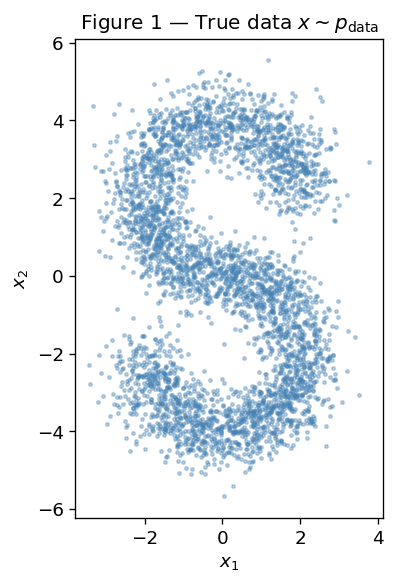

Dataset shape: torch.Size([4000, 2])


In [20]:
# ── generate S-curve ────────────────────────────────────────────────────────
N = 4000
t = 1.5 * math.pi * np.random.uniform(-1, 1, size=N)

sx = np.sin(t)
sy = np.sign(t) * (np.cos(t) - 1)

data_np = (2.0 * np.stack([sx, sy], axis=1)
           + np.random.normal(0, 0.50, size=(N, 2)))

data = torch.tensor(data_np, dtype=torch.float32)   # (N, 2)

# ── Figure 1: true data ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(data_np[:, 0], data_np[:, 1], s=4, alpha=0.35, color="steelblue")
ax.set_title(r"Figure 1 — True data $x \sim p_\mathrm{data}$", fontsize=12)
ax.set_xlabel(r"$x_1$"); ax.set_ylabel(r"$x_2$")
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("figures/fig1_true_data.png", dpi=200)
plt.show()
print(f"Dataset shape: {data.shape}")

## 3 — Decoder Network $g_\theta$

A small MLP maps $z \in \mathbb{R}^2$ to the Gaussian parameters $(\mu, \sigma)$:

$$z \;\xrightarrow{\text{Linear}(2 \to 128)}\; \tanh \;\xrightarrow{\text{Linear}(128 \to 128)}\; \tanh \;\xrightarrow{\text{Linear}(128 \to 4)}\; [\mu_{1:2},\; \log\sigma_{1:2}]$$

**Numerical stability:** we clamp $\log\sigma$ to $[-4, 1]$ before exponentiating,
keeping $\sigma \in [e^{-4}, e] \approx [0.018, 2.72]$.

In [41]:
class Decoder(nn.Module):
    # Maps z -> (mu, sigma) via a 2-layer MLP

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 4),          # 2 for mu + 2 for log_sigma
        )

    def forward(self, z):                       # z : (*, 2)
        out = self.net(z)                       # (*, 4)
        mu        = out[..., :2]                # (*, 2)
        log_sigma = out[..., 2:].clamp(-4., 1.)
        sigma     = torch.exp(log_sigma)        # (*, 2)  always positive
        return mu, sigma


decoder = Decoder().to(device)
n_params = sum(p.numel() for p in decoder.parameters())
print(f"Decoder parameters: {n_params:,}")


Decoder parameters: 17,412


## 4 — Training Objective: Maximum Likelihood

We want to find

$$\theta^* = \underset{\theta}{\arg\max} \sum_{i=1}^{N} \log p_\theta(x_i)$$

Each term requires evaluating the **marginal log-likelihood**:

$$\log p_\theta(x_i) = \log \int p_\theta(x_i \mid z)\, p(z)\, dz$$

**Problem \#1 — the integral is intractable.**
$p_\theta(x_i \mid z)$ is Gaussian in $x$ but not in $z$ (because $\mu_\theta(z)$ is a nonlinear
neural network), so we cannot integrate analytically.

## 5 — Trick \#2: Monte-Carlo Estimation of the Integral

Draw $M$ samples from the **fixed prior** $z^{(m)} \sim p(z) = \mathcal{N}(0, I)$:

$$p_\theta(x_i) \approx \frac{1}{M} \sum_{m=1}^{M} p_\theta\!\left(x_i \mid z^{(m)}\right)$$

Taking the log via the log-sum-exp trick:

$$\log p_\theta(x_i) \approx \underbrace{\log \sum_{m=1}^{M} p_\theta(x_i \mid z^{(m)})}_{\texttt{torch.logsumexp}} - \log M$$

Since the samples come from the *fixed* prior, gradients flow only through
$\mu_\theta$ and $\sigma_\theta$ — no reparameterisation is needed here.

In [42]:
# ── hyper-parameters ─────────────────────────────────────────────────────────
M          = 128    # Monte-Carlo samples per step
B          = 256    # mini-batch size
N_STEPS    = 14000
LR         = 1e-3
SNAP_EVERY = 50    # collect a decoder snapshot every N steps (for animation)
LOG_2PI    = math.log(2 * math.pi)

# fixed latent grid used for all snapshots — keeps them visually comparable
GRID_N_SNAP = 18
_g   = np.linspace(-2.5, 2.5, GRID_N_SNAP)
_G1, _G2 = np.meshgrid(_g, _g)
z_grid_snap = torch.tensor(
    np.stack([_G1.ravel(), _G2.ravel()], axis=1), dtype=torch.float32
)

snapshots = []   # list of {step, mu (G,G,2), sigma (G,G,2)}

optimizer = optim.Adam(decoder.parameters(), lr=LR)
loss_history = []

for step in range(N_STEPS):
    # 1) random mini-batch from the data
    idx     = torch.randint(0, len(data), (B,))
    x_batch = data[idx]                        # (B, 2)

    # 2) draw M latent vectors from the prior
    z = torch.randn(M, 2, device=device)       # (M, 2)

    # 3) decode: each z -> (mu, sigma)
    mu, sigma = decoder(z)                     # (M, 2) each

    # 4) broadcasting: x -> (B,1,2),  mu/sigma -> (1,M,2)
    x_b     = x_batch.unsqueeze(1)             # (B, 1, 2)
    mu_b    = mu.unsqueeze(0)                  # (1, M, 2)
    sigma_b = sigma.unsqueeze(0)               # (1, M, 2)

    # Gaussian log-density summed over d=2 dims  ->  (B, M)
    logN = (
        -0.5 * LOG_2PI
        - torch.log(sigma_b)
        - 0.5 * ((x_b - mu_b) / sigma_b) ** 2
    ).sum(dim=2)

    # 5) MC log-likelihood estimate  ->  (B,)
    log_px = torch.logsumexp(logN, dim=1) - math.log(M)

    # 6) negative mean log-likelihood
    loss = -log_px.mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

    if (step + 1) % SNAP_EVERY == 0:
        # save a snapshot of the necklace for the convergence animation
        decoder.eval()
        with torch.no_grad():
            mu_s, sig_s = decoder(z_grid_snap)
        decoder.train()
        snapshots.append({
            "step":  step + 1,
            "mu":    mu_s.numpy().reshape(GRID_N_SNAP, GRID_N_SNAP, 2).copy(),
            "sigma": sig_s.numpy().reshape(GRID_N_SNAP, GRID_N_SNAP, 2).copy(),
        })
        print(f"step {step+1:4d} | loss = {loss.item():.4f}")

print(f"\nTraining complete. {len(snapshots)} snapshots collected.")

step   50 | loss = 4.3000
step  100 | loss = 4.2644
step  150 | loss = 4.1816
step  200 | loss = 4.2680
step  250 | loss = 4.1283
step  300 | loss = 4.1002
step  350 | loss = 4.1414
step  400 | loss = 4.0711
step  450 | loss = 3.9867
step  500 | loss = 4.0036
step  550 | loss = 4.0976
step  600 | loss = 4.0382
step  650 | loss = 4.0875
step  700 | loss = 4.0070
step  750 | loss = 4.0854
step  800 | loss = 3.9913
step  850 | loss = 4.0084
step  900 | loss = 4.0814
step  950 | loss = 4.0522
step 1000 | loss = 4.0562
step 1050 | loss = 3.9743
step 1100 | loss = 4.0997
step 1150 | loss = 4.0875
step 1200 | loss = 4.0348
step 1250 | loss = 4.0572
step 1300 | loss = 4.1024
step 1350 | loss = 4.0008
step 1400 | loss = 4.0423
step 1450 | loss = 4.0478
step 1500 | loss = 4.0002
step 1550 | loss = 4.0559
step 1600 | loss = 4.0106
step 1650 | loss = 4.0477
step 1700 | loss = 4.0315
step 1750 | loss = 4.0975
step 1800 | loss = 3.9667
step 1850 | loss = 4.0360
step 1900 | loss = 4.0190
step 1950 | 

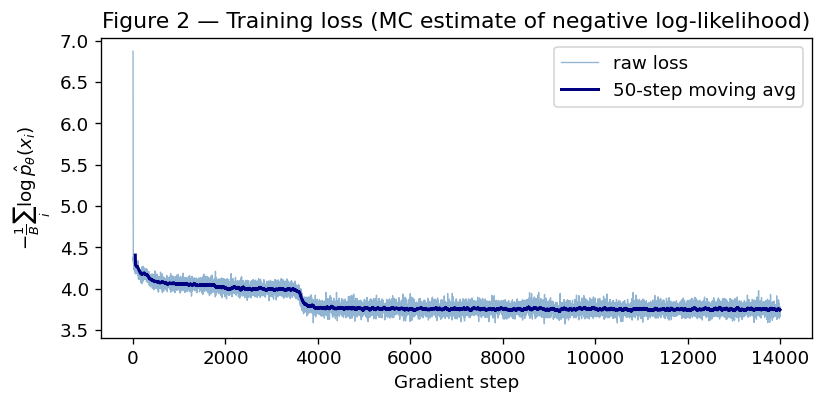

In [43]:
# ── Figure 2: training loss ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(loss_history, lw=0.8, alpha=0.6, color="steelblue", label="raw loss")

window = 50
avg = np.convolve(loss_history, np.ones(window) / window, mode="valid")
ax.plot(range(window - 1, len(loss_history)), avg,
        lw=1.8, color="navy", label=f"{window}-step moving avg")

ax.set_xlabel("Gradient step")
ax.set_ylabel(r"$-\frac{1}{B}\sum_i \log\hat{p}_\theta(x_i)$")
ax.set_title("Figure 2 — Training loss (MC estimate of negative log-likelihood)")
ax.legend()
plt.tight_layout()
plt.savefig("figures/fig2_training_loss.png", dpi=200)
plt.show()

## Animation 1 — Training Convergence

Each frame is a **snapshot** of the decoder's necklace taken every 500 gradient steps.
The warped grid and $1\sigma$ ellipses start random and gradually wrap onto the S-curve.

Saved as `figures/training_convergence.gif`.

In [45]:
# ── Animation 1: necklace convergence over training ─────────────────────────
fig_a1, ax_a1 = plt.subplots(figsize=(6, 6))

# faint true data (static backdrop)
ax_a1.scatter(data_np[:, 0], data_np[:, 1],
              s=3, alpha=0.12, color="grey", zorder=1)

# pre-create grid-line artists
_row_lines = [ax_a1.plot([], [], color="lightsteelblue",
                         lw=0.9, alpha=0.75, zorder=2)[0]
              for _ in range(GRID_N_SNAP)]
_col_lines = [ax_a1.plot([], [], color="lightsteelblue",
                         lw=0.9, alpha=0.75, zorder=2)[0]
              for _ in range(GRID_N_SNAP)]

# pre-create sigma-ellipses at every 3rd grid node
_STEP_E = 3
_ellipses_info = []
for _i in range(0, GRID_N_SNAP, _STEP_E):
    for _j in range(0, GRID_N_SNAP, _STEP_E):
        _ell = Ellipse((0, 0), width=0.1, height=0.1,
                       fill=False, edgecolor="steelblue",
                       lw=0.9, alpha=0.6, zorder=3)
        ax_a1.add_patch(_ell)
        _ellipses_info.append((_i, _j, _ell))

ax_a1.set_xlim(-5.5, 5.5); ax_a1.set_ylim(-5.5, 5.5)
ax_a1.set_aspect("equal")
ax_a1.set_xlabel(r"$x_1$"); ax_a1.set_ylabel(r"$x_2$")
_title_a1 = ax_a1.set_title("")
plt.tight_layout()


def _update_a1(frame):
    snap  = snapshots[frame]
    mu_g  = snap["mu"]
    sig_g = snap["sigma"]
    for _i, line in enumerate(_row_lines):
        line.set_data(mu_g[_i, :, 0], mu_g[_i, :, 1])
    for _j, line in enumerate(_col_lines):
        line.set_data(mu_g[:, _j, 0], mu_g[:, _j, 1])
    for _i, _j, _ell in _ellipses_info:
        _ell.center = (mu_g[_i, _j, 0], mu_g[_i, _j, 1])
        _ell.width  = 2 * sig_g[_i, _j, 0]
        _ell.height = 2 * sig_g[_i, _j, 1]
    _title_a1.set_text(
        f"Necklace after {snap['step']:,} gradient steps  (of {N_STEPS:,})"
    )
    return _row_lines + _col_lines + [e for _, _, e in _ellipses_info] + [_title_a1]


_anim1 = FuncAnimation(fig_a1, _update_a1,
                        frames=len(snapshots), interval=400, blit=False)
_anim1.save("figures/training_convergence.gif",
            writer=PillowWriter(fps=3), dpi=120)
plt.close(fig_a1)
print(f"Saved figures/training_convergence.gif  "
      f"({len(snapshots)} frames @ 3 fps)")

Saved figures/training_convergence.gif  (280 frames @ 3 fps)


## 6 — Visualising What the Model Learned

Three complementary static views:

| Figure | What it shows |
|--------|---------------|
| 3 | Latent samples $z \sim p(z)$ coloured by angle |
| 4 | How the latent plane *folds* onto data space: warped grid + $1\sigma$ ellipses |
| 5 | True data vs. reparameterised samples, colour-coded by latent angle |

/var/folders/lt/cbd6hs8j1_l7z2hdg5v533l80000gn/T/ipykernel_27304/1156335257.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(z_np[:, 0], z_np[:, 1],


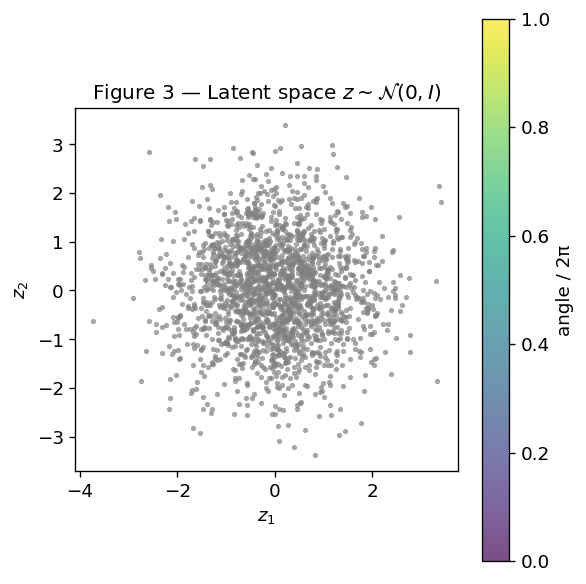

In [38]:
# ── Figure 3: latent-space scatter coloured by angle ─────────────────────────
n_viz  = 2000
z_viz  = torch.randn(n_viz, 2)
z_np   = z_viz.numpy()
angles = np.arctan2(z_np[:, 1], z_np[:, 0])
#c_viz  = (angles + math.pi) / (2 * math.pi)   # [0,1) for HSV colourmap

fig, ax = plt.subplots(figsize=(5, 5))
sc = ax.scatter(z_np[:, 0], z_np[:, 1],
                c='grey', cmap="hsv", s=10, alpha=0.7, linewidths=0)
plt.colorbar(sc, ax=ax, label="angle / 2π")
ax.set_title(r"Figure 3 — Latent space $z \sim \mathcal{N}(0,I)$", fontsize=12)
ax.set_xlabel(r"$z_1$"); ax.set_ylabel(r"$z_2$")
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("figures/fig3_latent_space.png", dpi=200)
plt.show()

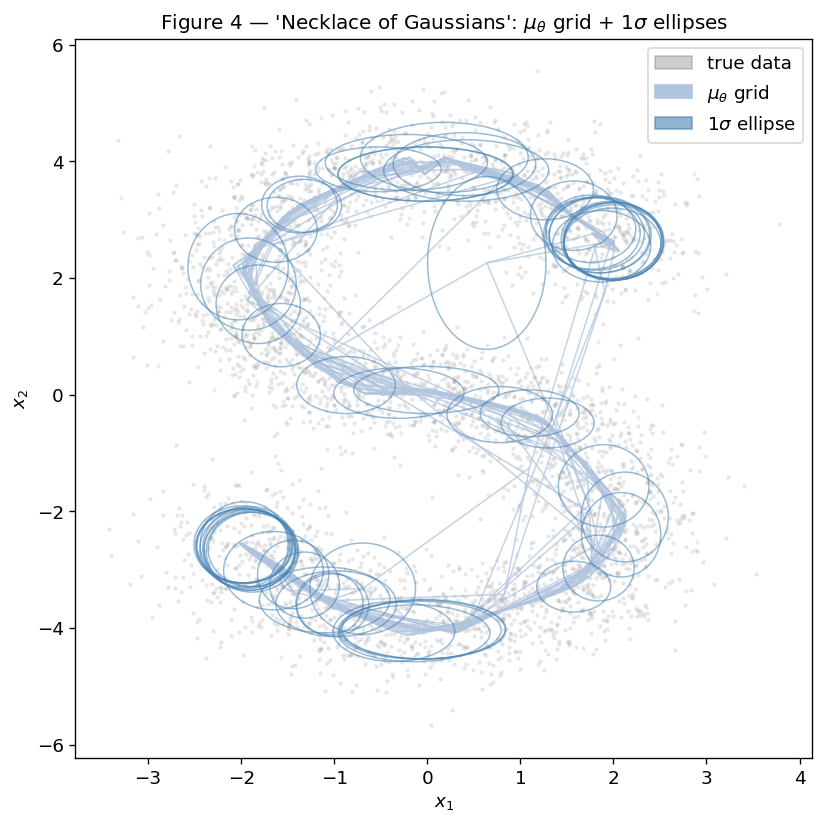

In [34]:
# ── Figure 4: necklace of Gaussians ─────────────────────────────────────────
GRID_N = 22
g      = np.linspace(-2.5, 2.5, GRID_N)
G1, G2 = np.meshgrid(g, g)
z_grid = torch.tensor(
    np.stack([G1.ravel(), G2.ravel()], axis=1), dtype=torch.float32
)

decoder.eval()
with torch.no_grad():
    mu_g, sigma_g = decoder(z_grid)
mu_g    = mu_g.numpy().reshape(GRID_N, GRID_N, 2)
sigma_g = sigma_g.numpy().reshape(GRID_N, GRID_N, 2)
decoder.train()

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(data_np[:, 0], data_np[:, 1],
           s=3, alpha=0.12, color="grey", zorder=1)
for i in range(GRID_N):
    ax.plot(mu_g[i, :, 0], mu_g[i, :, 1],
            color="lightsteelblue", lw=0.9, alpha=0.75, zorder=2)
    ax.plot(mu_g[:, i, 0], mu_g[:, i, 1],
            color="lightsteelblue", lw=0.9, alpha=0.75, zorder=2)
STEP_E = 3
for i in range(0, GRID_N, STEP_E):
    for j in range(0, GRID_N, STEP_E):
        mx, my = mu_g[i, j]
        ex, ey = sigma_g[i, j]
        ell = Ellipse((mx, my), width=2*ex, height=2*ey,
                      fill=False, edgecolor="steelblue", lw=0.9, alpha=0.55, zorder=3)
        ax.add_patch(ell)
ax.set_title(
    r"Figure 4 — 'Necklace of Gaussians': $\mu_\theta$ grid + $1\sigma$ ellipses",
    fontsize=12)
ax.set_xlabel(r"$x_1$"); ax.set_ylabel(r"$x_2$")
handles = [
    mpatches.Patch(color="grey",          alpha=0.4, label="true data"),
    mpatches.Patch(color="lightsteelblue",            label=r"$\mu_\theta$ grid"),
    mpatches.Patch(color="steelblue",     alpha=0.6, label=r"$1\sigma$ ellipse"),
]
ax.legend(handles=handles, loc="upper right")
plt.tight_layout()
plt.savefig("figures/fig4_necklace.png", dpi=200)
plt.show()

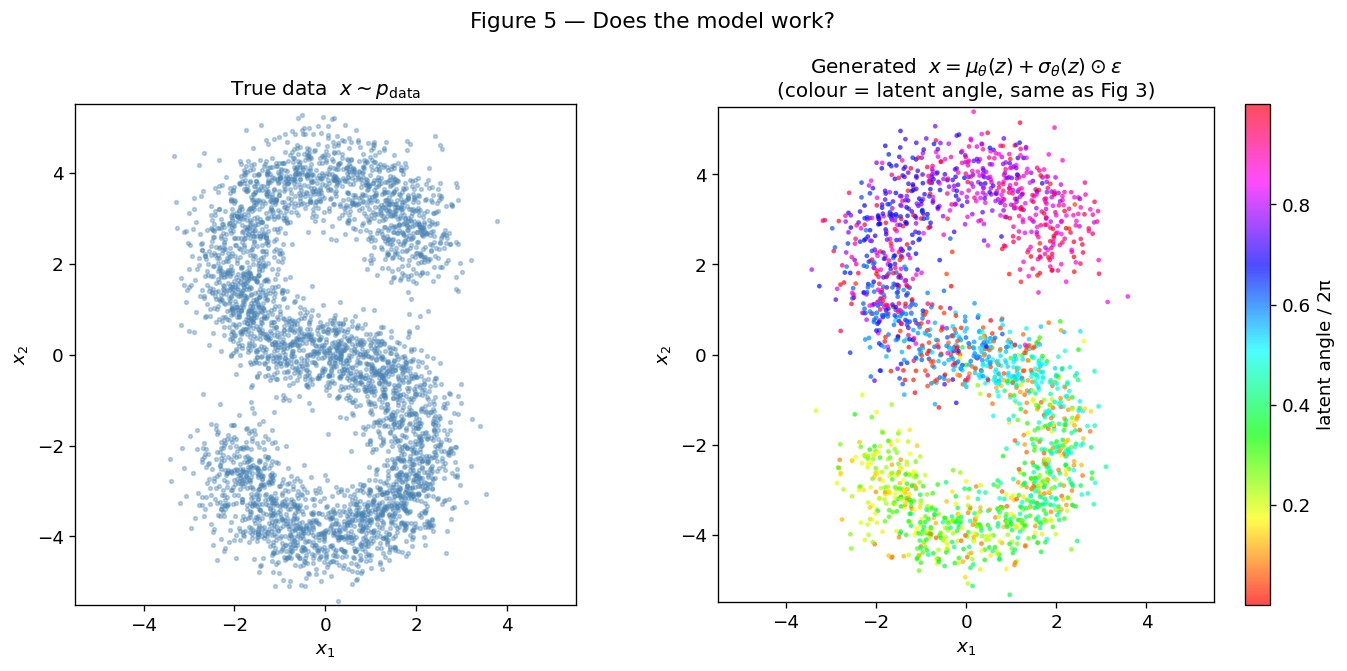

In [35]:
# ── Figure 5: generated vs. true data ────────────────────────────────────────
n_gen      = 2000
z_gen      = torch.randn(n_gen, 2)
z_gen_np   = z_gen.numpy()
angles_gen = np.arctan2(z_gen_np[:, 1], z_gen_np[:, 0])
c_gen      = (angles_gen + math.pi) / (2 * math.pi)

decoder.eval()
with torch.no_grad():
    mu_gen, sigma_gen = decoder(z_gen)
    eps   = torch.randn_like(mu_gen)
    x_gen = (mu_gen + sigma_gen * eps).numpy()  # reparameterised sample
decoder.train()

LIM = 5.5
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
axes[0].scatter(data_np[:, 0], data_np[:, 1],
                s=5, alpha=0.35, color="steelblue")
axes[0].set_title(r"True data  $x \sim p_\mathrm{data}$", fontsize=12)
axes[0].set_xlim(-LIM, LIM); axes[0].set_ylim(-LIM, LIM)
axes[0].set_aspect("equal")
axes[0].set_xlabel(r"$x_1$"); axes[0].set_ylabel(r"$x_2$")

sc = axes[1].scatter(x_gen[:, 0], x_gen[:, 1],
                     c=c_gen, cmap="hsv", s=8, alpha=0.7, linewidths=0)
axes[1].set_title(
    r"Generated  $x = \mu_\theta(z) + \sigma_\theta(z)\odot\varepsilon$"
    "\n(colour = latent angle, same as Fig 3)", fontsize=12)
axes[1].set_xlim(-LIM, LIM); axes[1].set_ylim(-LIM, LIM)
axes[1].set_aspect("equal")
axes[1].set_xlabel(r"$x_1$"); axes[1].set_ylabel(r"$x_2$")
plt.colorbar(sc, ax=axes[1], label="latent angle / 2π")
plt.suptitle("Figure 5 — Does the model work?", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("figures/fig5_generated_vs_true.png", dpi=200, bbox_inches="tight")
plt.show()

## Animation 2 — Single $z$ Sweeping Through Latent Space

We trace a circular path of radius 1.5 through the latent plane.

- **Left panel:** the $z$ dot moving around the circle (colour = HSV angle, same palette as Fig 3).
- **Right panel:** the corresponding $\mu_\theta(z)$ and $1\sigma$ ellipse sliding along the S-curve.

The faint grid in the right panel is the full trained necklace from the last training snapshot.
Saved as `figures/necklace_sweep.gif`.

In [37]:
import matplotlib
# ── Animation 2: single z sweeping along a circle ───────────────────────────
N_SWEEP = 90                           # frames = one full revolution
_theta  = np.linspace(0, 2 * math.pi, N_SWEEP, endpoint=False)
_R      = 1.0

z_path = torch.tensor(
    np.stack([_R * np.cos(_theta), _R * np.sin(_theta)], axis=1),
    dtype=torch.float32,
)                                      # (N_SWEEP, 2)

# colour each frame by latent angle — same HSV palette as Figure 3
_c_sweep = _theta / (2 * math.pi)     # [0, 1)

decoder.eval()
with torch.no_grad():
    _mu_path, _sig_path = decoder(z_path)
_mu_path  = _mu_path.numpy()           # (N_SWEEP, 2)
_sig_path = _sig_path.numpy()          # (N_SWEEP, 2)
decoder.train()

# ── figure layout ─────────────────────────────────────────────────────────────
fig_a2, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(12, 5.5))

# left: latent space
ax_l.set_xlim(-3, 3); ax_l.set_ylim(-3, 3); ax_l.set_aspect("equal")
ax_l.set_title(r"Latent space: $z$ position", fontsize=12)
ax_l.set_xlabel(r"$z_1$"); ax_l.set_ylabel(r"$z_2$")
ax_l.plot(z_path[:, 0].numpy(), z_path[:, 1].numpy(),
          color="grey", lw=1.2, alpha=0.35, zorder=1)      # faint circle
_dot_l, = ax_l.plot([], [], "o", ms=10, zorder=3)

# right: data space — use last snapshot as the static necklace backdrop
_last_snap = snapshots[-1]
for _i in range(GRID_N_SNAP):
    ax_r.plot(_last_snap["mu"][_i, :, 0], _last_snap["mu"][_i, :, 1],
              color="lightsteelblue", lw=0.7, alpha=0.35, zorder=1)
    ax_r.plot(_last_snap["mu"][:, _i, 0], _last_snap["mu"][:, _i, 1],
              color="lightsteelblue", lw=0.7, alpha=0.35, zorder=1)
ax_r.scatter(data_np[:, 0], data_np[:, 1],
             s=3, alpha=0.12, color="grey", zorder=0)
ax_r.set_xlim(-5.5, 5.5); ax_r.set_ylim(-5.5, 5.5); ax_r.set_aspect("equal")
ax_r.set_title(r"Data space: $\mu_\theta(z) \pm 1\,\sigma_\theta(z)$", fontsize=12)
ax_r.set_xlabel(r"$x_1$"); ax_r.set_ylabel(r"$x_2$")

_ell_sweep = Ellipse((0, 0), 0.1, 0.1,
                     fill=False, edgecolor="firebrick", lw=2.5, alpha=0.9, zorder=4)
ax_r.add_patch(_ell_sweep)
_dot_r, = ax_r.plot([], [], "o", ms=7, zorder=5)
_sup = fig_a2.suptitle("", fontsize=12, y=1.01)
plt.tight_layout()

_hsv = matplotlib.colormaps["hsv"]


def _update_a2(frame):
    c     = _c_sweep[frame]
    color = _hsv(c)
    mu_c  = _mu_path[frame]
    sig_c = _sig_path[frame]
    z_c   = z_path[frame].numpy()

    # latent dot
    _dot_l.set_data([z_c[0]], [z_c[1]])
    _dot_l.set_color(color)

    # data space: ellipse + centre dot
    _ell_sweep.center = (mu_c[0], mu_c[1])
    _ell_sweep.width  = 2 * sig_c[0]
    _ell_sweep.height = 2 * sig_c[1]
    _ell_sweep.set_edgecolor(color)
    _dot_r.set_data([mu_c[0]], [mu_c[1]])
    _dot_r.set_color(color)

    _sup.set_text(
        rf"$z = ({z_c[0]:.2f},\;{z_c[1]:.2f})$"
        r"  $\longrightarrow$  "
        rf"$\mu = ({mu_c[0]:.2f},\;{mu_c[1]:.2f})$"
    )
    return _dot_l, _ell_sweep, _dot_r, _sup


_anim2 = FuncAnimation(fig_a2, _update_a2,
                        frames=N_SWEEP, interval=60, blit=False)
_anim2.save("figures/necklace_sweep.gif",
            writer=PillowWriter(fps=18), dpi=120)
plt.close(fig_a2)
print(f"Saved figures/necklace_sweep.gif  ({N_SWEEP} frames @ 18 fps)")

Saved figures/necklace_sweep.gif  (90 frames @ 18 fps)


## 7 — What We See, and the Catch

### What works
Figure 5 shows the 2-D Gaussian blob in latent space has been **warped onto the S**.
Animation 2 makes this literal: a single dot tracing a circle in $z$-space produces a
$\mu_\theta(z)$ dot that rides the S-curve, with its $\sigma$-ellipse varying in size.
The aggregate distribution in Figure 5 visually matches $p_\text{data}$.

### The catch: high-variance MC gradients
Look at the training loss (Fig 2) and the convergence animation: learning is noisy
and the necklace takes many steps to align.

Why?  For a given $x_i$, most of the $M = 128$ prior samples $z^{(m)}$ have nothing
to do with $x_i$ — they are drawn blindly from the full prior ball, not guided
toward the part of $z$-space that explains $x_i$.
So nearly every term in

$$\log p_\theta(x_i) \approx \log\!\left(\frac{1}{M}\sum_m p_\theta(x_i \mid z^{(m)})\right)$$

is essentially zero, and the log-sum-exp is dominated by rare lucky hits.
This makes the gradient estimator **high-variance**.

### The fix — Notebook 2
Instead of sampling $z$ from the blind prior, we will learn an **encoder**
$q_\phi(z \mid x)$ that proposes $z$'s that actually explain each $x_i$.
This turns the intractable log-marginal into a tractable lower bound — the **ELBO** —
and is the core idea behind **Variational Autoencoders (VAEs)**.